# Train on 2017, test on 2018

**Question.** Can a model trained only on CIC-IDS2017 be made to generalize to CSE-CIC-IDS2018,
a year later on a different network?

`notebooks/cross_year_diagnostics.ipynb` found three causes of the failure: the flow tool
measured header-based features differently, the networks and attack tools differ, and the class
mix differs. This notebook tests two fixes aimed at the first two causes (code in
`src/models/cross_dataset.py`):

| Variant | What changes |
|---|---|
| `baseline` | all 71 features, one scaler fit on the training year |
| `drop_header` | drop the 3 header-length features the flow tool measured differently in the two years (`min_seg_size_forward`, `Fwd/Bwd Header Length`) |
| `drop_network` | drop destination port and the 2 initial TCP window sizes, which describe one particular network |
| `per_domain` | each year is quantile-normalized on its **own unlabeled traffic**, so values mean "how unusual for this network" |
| `header_and_domain` | `drop_header` + `per_domain` |

Each variant trains logistic regression and LightGBM on 2017 (benign downsampled to 200k in
training only) and is tested on a held-out 20% of 2017 and on all of 2018.

**Written before the first run.** We expected removing tool- and network-dependent features, and
normalizing each year on its own traffic, to help most on attack types that look alike in both
years (slowloris, Bot) and little on types whose behaviour changed (DoS Hulk, SSH brute force).
The first run dropped the header and network features together in one variant, and LightGBM got
much worse. This version drops them separately to see which group matters. No variant is chosen
using 2018 labels: all five are reported.

**Metrics.** PR-AUC (2018 benign rows weighted by 10 to undo the 10% sample) and recall at a 1%
false positive rate. The 1% threshold is set on each test set's own benign flows, which is
optimistic but gives every model the same alert budget.

In [1]:
import sys
sys.path.insert(0, "..")  # make src/ importable from notebooks/

import json
import warnings
import matplotlib.pyplot as plt
import pandas as pd

from src.models.cross_dataset import run_direction

warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.width", 200)

SOURCE, TARGET = "2017", "2018"
summary, per_family = run_direction(SOURCE, TARGET)

## Results

In [2]:
summary.round(3)

n features  PR-AUC  no-skill  recall at 1% FPR
variant           model               test set                                                         
baseline          Logistic regression 2017 held-out              71   0.954     0.169             0.742
                                      2018 (other year)          71   0.297     0.103             0.026
                  LightGBM            2017 held-out              71   1.000     0.169             1.000
                                      2018 (other year)          71   0.557     0.103             0.380
drop_header       Logistic regression 2017 held-out              68   0.944     0.169             0.639
                                      2018 (other year)          68   0.167     0.103             0.008
                  LightGBM            2017 held-out              68   1.000     0.169             1.000
                                      2018 (other year)          68   0.504     0.103             0.229
drop_network      Logistic regression 2017 held-out              68   0.949     0.169             0.777
                                      2018 (other year)          68   0.202     0.103             0.006
                  LightGBM            2017 held-out              68   0.999     0.169             0.997
                                      2018 (other year)          68   0.400     0.103             0.075
per_domain        Logistic regression 2017 held-out              71   0.988     0.169             0.981
                                      2018 (other year)          71   0.350     0.103             0.264
                  LightGBM            2017 held-out              71   0.999     0.169             1.000
                                      2018 (other year)          71   0.312     0.103             0.002
header_and_domain Logistic regression 2017 held-out              68   0.983     0.169             0.974
                                      2018 (other year)          68   0.311     0.103             0.197
                  LightGBM            2017 held-out              68   1.000     0.169             1.000
                                      2018 (other year)          68   0.312     0.103             0.009

In [3]:
# Same year vs. other year, side by side
pivot = summary["PR-AUC"].unstack("test set").round(3)
pivot["drop"] = (pivot.iloc[:, 0] - pivot.iloc[:, 1]).round(3)
pivot

test set                               2017 held-out  2018 (other year)   drop
variant           model                                                       
baseline          LightGBM                     1.000              0.557  0.443
                  Logistic regression          0.954              0.297  0.657
drop_header       LightGBM                     1.000              0.504  0.496
                  Logistic regression          0.944              0.167  0.777
drop_network      LightGBM                     0.999              0.400  0.599
                  Logistic regression          0.949              0.202  0.747
header_and_domain LightGBM                     1.000              0.312  0.688
                  Logistic regression          0.983              0.311  0.672
per_domain        LightGBM                     0.999              0.312  0.687
                  Logistic regression          0.988              0.350  0.638

### Which attack families does each variant catch in 2018?

Recall per attack family at the 1% false positive threshold, on the other year's data.

In [4]:
other = [c for c in per_family.columns if "other year" in c[2]]
per_family[other].droplevel(2, axis=1).round(3)

baseline                  drop_header                 drop_network                   per_domain            header_and_domain         
                      Logistic regression LightGBM Logistic regression LightGBM Logistic regression LightGBM Logistic regression LightGBM Logistic regression LightGBM
Bot                                 0.000    0.000               0.000    0.000               0.000    0.000               0.000    0.000               0.000    0.000
Brute force (FTP/SSH)               0.000    0.972               0.000    0.850               0.000    0.000               0.026    0.000               0.006    0.000
DDoS                                0.011    0.326               0.012    0.262               0.005    0.107               0.324    0.000               0.324    0.000
DoS                                 0.065    0.755               0.007    0.122               0.018    0.088               0.420    0.007               0.058    0.057
Heartbleed                            NaN      NaN                 NaN      NaN                 NaN      NaN                 NaN      NaN                 NaN      NaN
Infiltration                        0.102    0.135               0.007    0.001               0.007    0.000               0.139    0.010               0.015    0.008
PortScan                              NaN      NaN                 NaN      NaN                 NaN      NaN                 NaN      NaN                 NaN      NaN
Web attack                          0.000    0.512               0.000    0.011               0.000    0.004               0.001    0.033               0.000    0.023

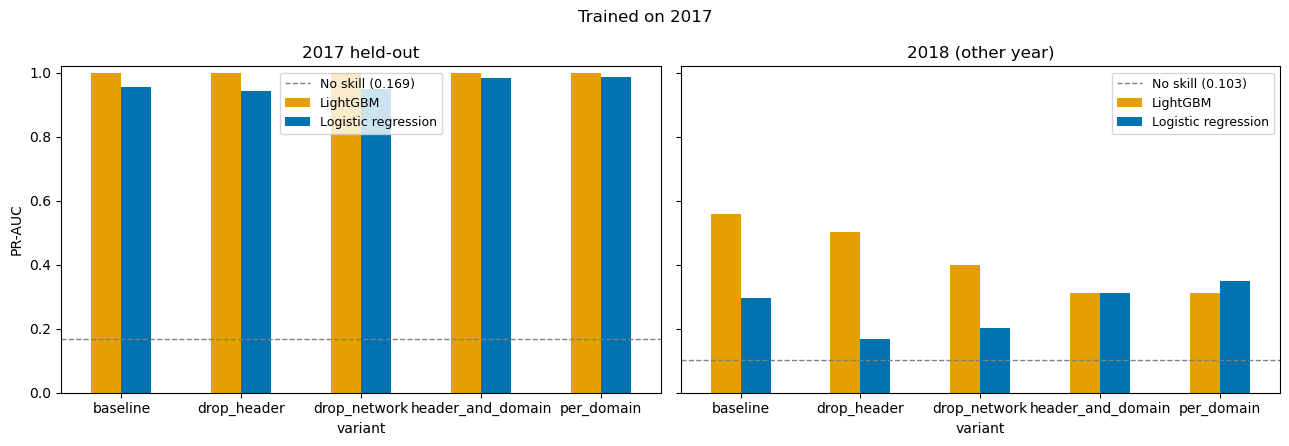

In [5]:
# Okabe-Ito colorblind-safe palette
colors = {"Logistic regression": "#0072B2", "LightGBM": "#E69F00"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, test_set in zip(axes, summary.index.get_level_values("test set").unique()):
    data = summary.xs(test_set, level="test set")["PR-AUC"].unstack("model")
    data.plot.bar(ax=ax, color=[colors[m] for m in data.columns], rot=0)
    no_skill = summary.xs(test_set, level="test set")["no-skill"].iloc[0]
    ax.axhline(no_skill, color="gray", linestyle="--", linewidth=1, label=f"No skill ({no_skill:.3f})")
    ax.set_title(test_set)
    ax.set_xlabel("variant")
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=9)
axes[0].set_ylabel("PR-AUC")
fig.suptitle(f"Trained on {SOURCE}")
fig.tight_layout()
plt.show()

In [6]:
# Save for the README and reports
out = {
    "summary": summary.reset_index().to_dict(orient="records"),
    "per_family_other_year": {f"{v} | {m}": col for (v, m, t), col in per_family.to_dict().items() if "other year" in t},
}
with open(f"../reports/cross_year_train_{SOURCE}_test_{TARGET}.json", "w") as fh:
    json.dump(out, fh, indent=2)

## Summary

All numbers are from the tables above. One seed and one split; the 1% threshold is set on 2018's
own benign flows, which is optimistic.

**Every variant works in-year and loses a lot across years.** On held-out 2017 every model scores
PR-AUC 0.94 or higher. On 2018 the drop is 0.44 to 0.78.

**The best transfer is the plain 71-feature LightGBM.** PR-AUC 0.557 against a no-skill of 0.103,
and recall 0.380 at a 1% false positive rate: brute force 0.972, DoS 0.755, web attacks 0.512,
DDoS 0.326. The 20-feature production LightGBM caught 0.004 of 2018 attacks
(`reports/cross_dataset_2018.md`), so the extra 51 features matter.

**The hypothesis was wrong for LightGBM.** Every fix made it worse:
- Dropping destination port and TCP window took brute-force recall from 0.972 to 0.000. Brute
  force targets the login port (21, 22) in both years, so the port is a real signal, not a
  network quirk.
- Dropping the header-length features took DoS from 0.755 to 0.122 and web attacks from 0.512 to
  0.011. The measurement difference found in the diagnostics was for UDP flows; these attacks run
  over TCP.
- Per-domain normalization took LightGBM from 0.380 to 0.002.

**Per-domain normalization did help logistic regression:** recall 0.026 to 0.264, with DoS 0.065
to 0.420 and DDoS 0.011 to 0.324.

**Not fixed by anything:** Bot is 0.000 in every variant, and Infiltration is at most 0.139.